In [11]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from sklearn.metrics import roc_auc_score, average_precision_score
from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [12]:
# ============================================================
# Parameters
# ============================================================

# Variant classes to evaluate. Set to None to run all available classes.
# Available: missense, missense_structured, missense_non_structured,
#            missense_disordered, missense_lip, intron,
#            enhancer_encode, promoter_encode, tf_encode,
#            proximal_promoter, core_promoter, all_variants, all_non_coding
selected_variant_classes = [
    'missense',
    # 'missense_structured',
    # 'missense_non_structured',
    # 'missense_lip',
    # 'intron',
    # 'enhancer_encode',
    # 'promoter_encode',
    # 'tf_encode',
    # 'all_variants',
]
# selected_variant_classes = None  # uncomment to run all

# ClinVar labels classified as Pathogenic
patho_labels = ['Pathogenic', 'Likely_pathogenic']

# ClinVar labels classified as Benign.
# If None, all variants NOT matching patho_labels are used as Benign.
benign_labels = ['Benign', 'Likely_benign']
# benign_labels = None  # uncomment to use all non-pathogenic as benign

LOCAL_ANNO_DIR = "/s/project/deeprvat/ukb_gym/variant_files"
variant_class_path = "config_variant_classes.yaml"
config_pheno_path = "config_pheno.yaml"

In [13]:
# Load variant class config
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

# Load annotation tool config and build dataframe
with open(config_pheno_path) as f:
    pheno_config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in pheno_config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df["annotation"].to_list()

print(f"Annotation categories: {anno_config_df['category'].unique().to_list()}")
print(f"Total annotations: {len(all_annotation_list)}")
anno_config_df

Annotation categories: ['missense', 'protein_domains', 'indel_lengths', 'encode_regions', 'plof', 'regulatory', 'plof_consequences', 'conservation', 'dubious_plof', '5utr', 'splicing', 'encode_custom', 'coding_indels', '3utr', 'genetic_diversity', 'loftee_protein_domains', 'clinvar']
Total annotations: 67


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""coding_indels""","""inframe_deletion""","""#C6DBEF""","""inframe deletion""",1
"""coding_indels""","""inframe_insertion""","""#C6DBEF""","""inframe insertion""",1
"""coding_indels""","""consequence_synonymous_variant""","""#C6DBEF""","""synonymous""",1


In [14]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym"
CLIN_ANNO_FILE = "clinvar_variants_annotations_with_all_no_dup.parquet"

# LOCAL_ANNO_DIR = "/s/project/deeprvat/ukb_gym/annotation_files/clinvar/annotate_variants"
# LOCAL_ANNO_DIR = "/s/project/deeprvat/ukb_gym/variant_files"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

!dx download {RAP_ANNO_DIR}/{CLIN_ANNO_FILE} -o {LOCAL_ANNO_DIR}/{CLIN_ANNO_FILE}

# Load ClinVar annotations (lazy), apply SNV filter, add derived columns
clinvar_anno = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{CLIN_ANNO_FILE}")
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        (pl.col('ref').str.len_chars() == 1) & (pl.col('alt').str.len_chars() == 1)
    )
    .with_columns(
        promoterai_under=pl.col('promoterai'),
        promoterai_abs=pl.col('promoterai').abs(),
    )
)

schema_cols = clinvar_anno.collect_schema().names()
available_annos = [c for c in all_annotation_list if c in schema_cols]
print(f"Total columns: {len(schema_cols)}")
print(f"Available annotation columns: {len(available_annos)} / {len(all_annotation_list)}")
print(f"Unique clinical_significance values:")
clinvar_anno.select('clinical_significance').collect()['clinical_significance'].value_counts(sort=True)

Error: path
"/home/dnanexus/data_dir/clinvar_variants_annotations_with_all_no_dup.parquet"
already exists but -f/--overwrite was not set
Total columns: 201
Available annotation columns: 42 / 67
Unique clinical_significance values:


clinical_significance,count
str,u64
"""Uncertain_significance""",554917
"""Likely_benign""",167460
null,59453
"""Benign""",31965
"""Conflicting_classifications_of…",18832
…,…
"""Benign|association""",1
"""Benign|Affects""",1
"""VUS-mid""",1


In [15]:
def label_matches(series: pl.Series, labels: list) -> pl.Series:
    """Return boolean mask: True if clinical_significance contains any of the given labels.
    Handles compound values like 'Benign/Likely_benign'."""
    mask = pl.Series([False] * len(series))
    for lbl in labels:
        mask = mask | series.str.contains(lbl, literal=True).fill_null(False)
    return mask


def compute_metrics_for_class(
    vc_name: str,
    vc_config: dict,
    clinvar_anno: pl.LazyFrame,
    anno_config_df: pl.DataFrame,
    patho_labels: list,
    benign_labels,
) -> pl.DataFrame | None:
    vc_filters = vc_config.get('variant_filtering') or []
    tool_categories = vc_config.get('tool_categories', [])
    x_label = vc_config.get('x_label', vc_name)

    # Annotation tools for this variant category
    selected_annos_cfg = anno_config_df.filter(pl.col('category').is_in(tool_categories))
    anno_cols_in_schema = [
        c for c in selected_annos_cfg['annotation'].to_list()
        if c in clinvar_anno.collect_schema().names()
    ]

    if not anno_cols_in_schema:
        print(f"  {vc_name}: no annotation columns available, skipping")
        return None

    # Build and apply variant-class filters
    _dynamic_filters = [eval(f) for f in vc_filters] if vc_filters else []
    try:
        df = (
            clinvar_anno
            .filter(*_dynamic_filters)
            .select(['id', 'clinical_significance'] + anno_cols_in_schema)
            .collect()
        )
    except Exception as e:
        print(f"  {vc_name}: error loading — {e}")
        return None

    clin_sig = df['clinical_significance'].fill_null('')

    # Build pathogenic / benign masks
    patho_mask = label_matches(clin_sig, patho_labels)

    if benign_labels is None:
        benign_mask = ~patho_mask
    else:
        benign_mask = label_matches(clin_sig, benign_labels)

    df = df.with_columns(
        is_patho=patho_mask.cast(pl.Int8),
        is_benign=benign_mask.cast(pl.Int8),
    ).filter(patho_mask | benign_mask)

    n_patho = int(df['is_patho'].sum())
    n_benign = int(df['is_benign'].sum())

    if n_patho == 0 or n_benign == 0:
        print(f"  {vc_name}: n_patho={n_patho}, n_benign={n_benign} — skipping")
        return None

    print(f"  {vc_name}: {n_patho} pathogenic, {n_benign} benign, total={df.shape[0]}")

    results = []
    for row in selected_annos_cfg.iter_rows(named=True):
        anno = row['annotation']
        if anno not in df.columns:
            continue

        anno_dir = row['annotation_dir']
        sub = df.select(['is_patho', anno]).drop_nulls()
        if sub.shape[0] < 10:
            continue

        y_true = sub['is_patho'].to_numpy()
        y_score = sub[anno].to_numpy().astype(float) * anno_dir

        if y_true.sum() == 0 or y_true.sum() == len(y_true):
            continue

        try:
            auroc = float(roc_auc_score(y_true, y_score))
            auprc = float(average_precision_score(y_true, y_score))
        except Exception:
            continue

        results.append({
            'variant_class': vc_name,
            'x_label': x_label,
            'annotation': anno,
            'label': row['label'],
            'color': row['color'],
            'auroc': auroc,
            'auprc': auprc,
            'n_patho': n_patho,
            'n_benign': n_benign,
        })

    return pl.DataFrame(results) if results else None

In [16]:
# Run for all (or selected) variant classes
vc_names = selected_variant_classes or list(variant_class_config.keys())

all_results = []
for vc_name in vc_names:
    vc_config = variant_class_config[vc_name]
    print(f"Processing: {vc_name}")
    result = compute_metrics_for_class(
        vc_name, vc_config, clinvar_anno, anno_config_df, patho_labels, benign_labels
    )
    if result is not None:
        all_results.append(result)

results_df = pl.concat(all_results) if all_results else pl.DataFrame()
print(f"\nTotal: {results_df.shape[0]} rows across {results_df['variant_class'].n_unique()} variant classes")
results_df

Processing: missense


  missense: 5500 pathogenic, 28428 benign, total=33928

Total: 12 rows across 1 variant classes


variant_class,x_label,annotation,label,color,auroc,auprc,n_patho,n_benign
str,str,str,str,str,f64,f64,i64,i64
"""missense""","""Missense""","""am_pathogenicity""","""AlphaMissense""","""#feb72d""",0.911526,0.834661,5500,28428
"""missense""","""Missense""","""esmscoremissense""","""ESM1v""","""#feb72d""",0.903471,0.783603,5500,28428
"""missense""","""Missense""","""cpt1_llr""","""CPT-1""","""#feb72d""",0.89664,0.821307,5500,28428
"""missense""","""Missense""","""revel_score""","""REVEL""","""#feb72d""",0.91423,0.838661,5500,28428
"""missense""","""Missense""","""clinpred_score""","""ClinPred""","""#feb72d""",0.981729,0.934944,5500,28428
…,…,…,…,…,…,…,…,…
"""missense""","""Missense""","""verphylop""","""Vertebrate PhyloP""","""#942C80""",0.908029,0.626428,5500,28428
"""missense""","""Missense""","""zooverphylop""","""Zoonomia Vertebrate PhyloP""","""#942C80""",0.874905,0.495712,5500,28428
"""missense""","""Missense""","""mamphylop""","""Mammalian PhyloP""","""#942C80""",0.868629,0.462554,5500,28428


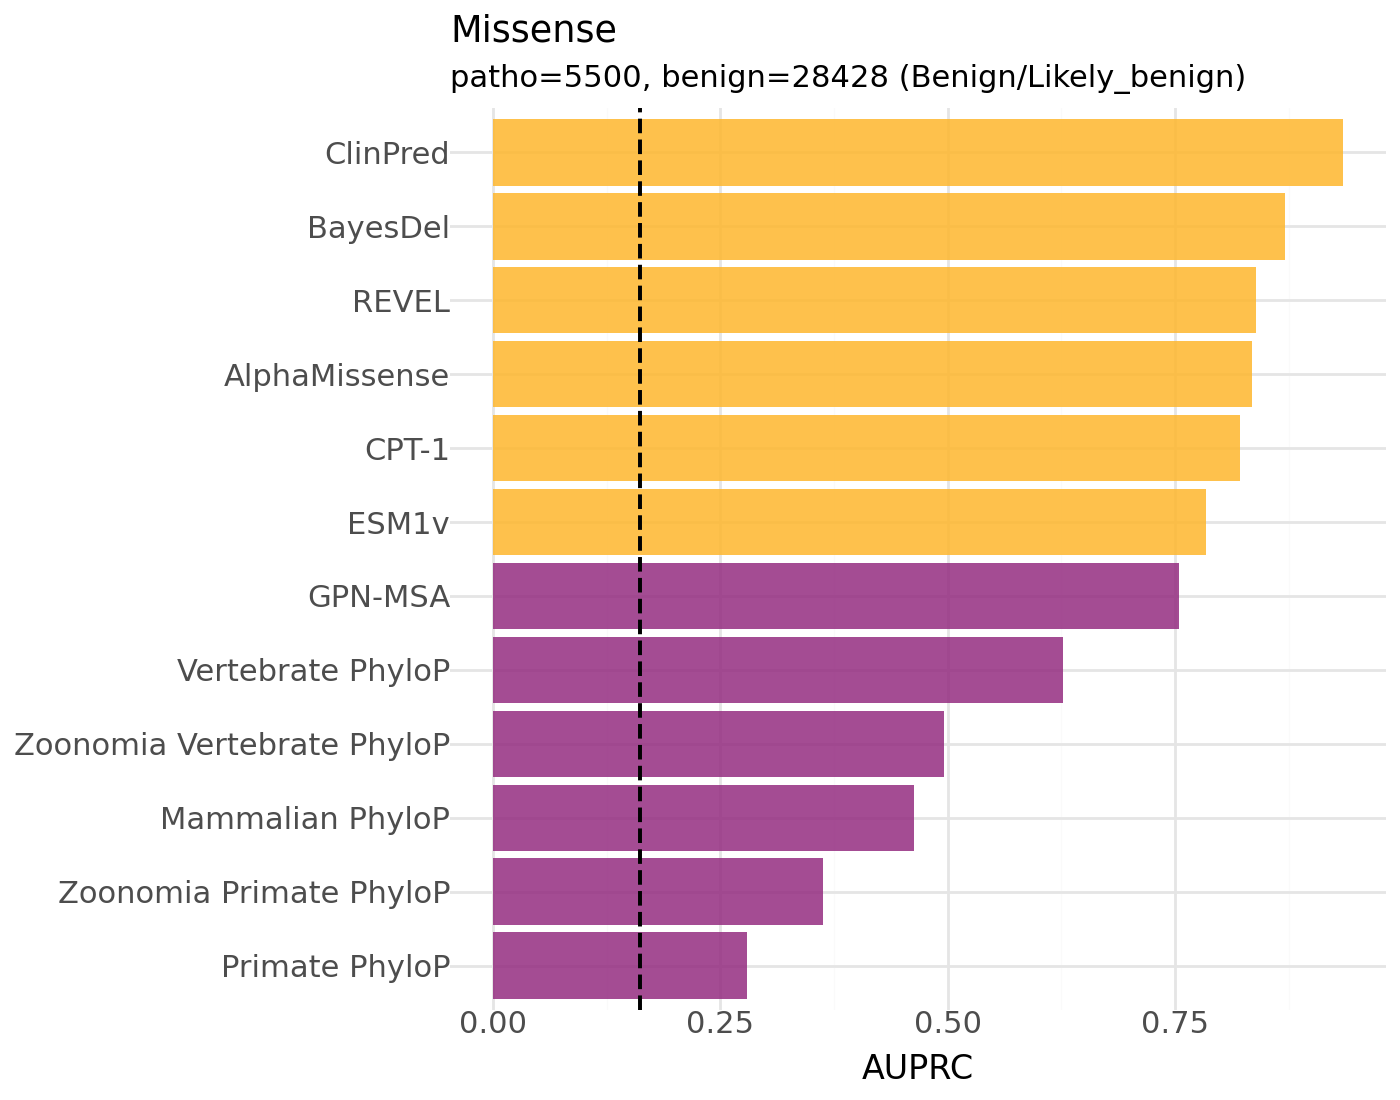

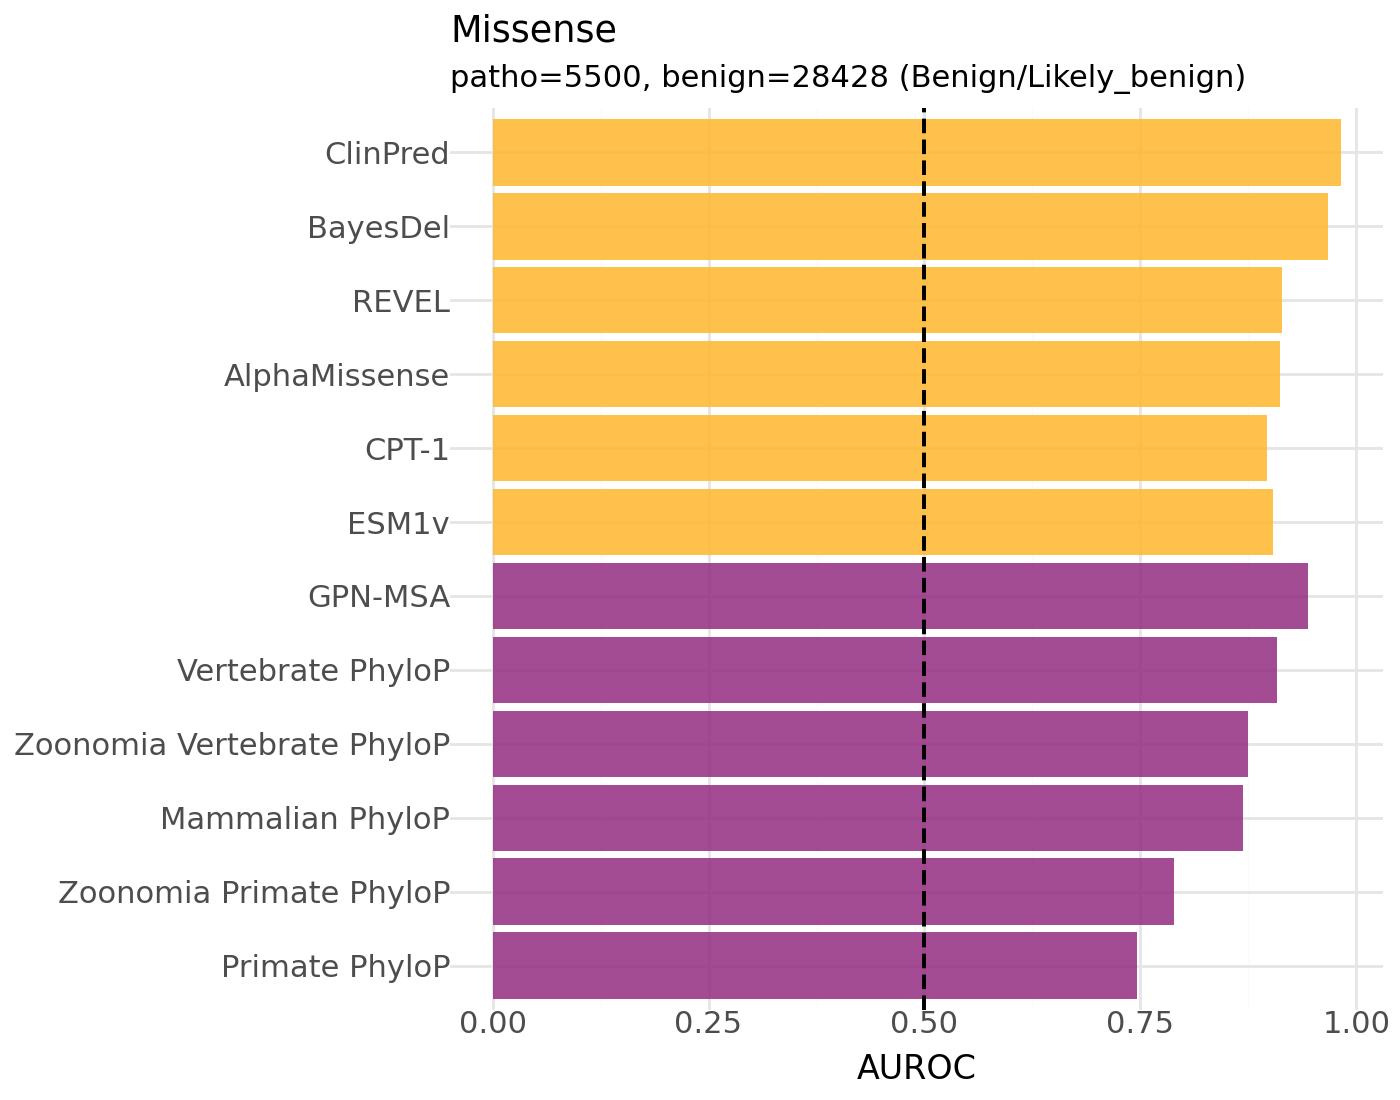

In [17]:
# auPRC and auROC — one plot per metric per variant category, sorted by auPRC descending
benign_desc = 'all non-pathogenic' if benign_labels is None else '/'.join(benign_labels)

for vc_name in results_df['variant_class'].unique().to_list():
    vc_results = results_df.filter(pl.col('variant_class') == vc_name)
    x_label = vc_results['x_label'][0]
    n_patho = vc_results['n_patho'][0]
    n_benign = vc_results['n_benign'][0]
    random_baseline = n_patho / (n_patho + n_benign)

    auprc_order = vc_results.sort('auprc', descending=False)['label'].to_list()
    plot_df = vc_results.with_columns(label=pl.col('label').cast(pl.Enum(auprc_order)))
    color_dict = dict(plot_df.select(['annotation', 'color']).unique().iter_rows())

    for metric, y_lab, baseline in [
        ('auprc', 'AUPRC', random_baseline),
        ('auroc', 'AUROC', 0.5),
    ]:
        p = (
            ggplot(plot_df, aes(x='label', y=metric, fill='annotation'))
            + geom_col(alpha=0.85)
            + geom_hline(yintercept=baseline, linetype='dashed', color='black', size=0.8)
            + coord_flip()
            + theme_minimal()
            + scale_fill_manual(values=color_dict)
            + labs(
                x='', y=y_lab,
                title=f"{x_label}",
                subtitle=f"patho={n_patho}, benign={n_benign} ({benign_desc})",
            )
            + theme(
                figure_size=(7, len(auprc_order) / 3 + 1.5),
                legend_position='none',
                axis_text=element_text(size=11),
                axis_title=element_text(size=12),
                plot_background=element_rect(fill='white', color='white'),
            )
        )
        p.show()

In [18]:
# Minimum number of pathogenic variants required per gene to compute metrics
MIN_PATHO_PER_GENE = 3


def compute_gene_metrics(
    vc_name: str,
    vc_config: dict,
    clinvar_anno: pl.LazyFrame,
    anno_config_df: pl.DataFrame,
    patho_labels: list,
    benign_labels,
    min_patho: int = MIN_PATHO_PER_GENE,
) -> pl.DataFrame | None:
    """Compute auROC/auPRC per gene (region) for a given variant class."""
    vc_filters = vc_config.get('variant_filtering') or []
    tool_categories = vc_config.get('tool_categories', [])
    x_label = vc_config.get('x_label', vc_name)

    selected_annos_cfg = anno_config_df.filter(pl.col('category').is_in(tool_categories))
    anno_cols_in_schema = [
        c for c in selected_annos_cfg['annotation'].to_list()
        if c in clinvar_anno.collect_schema().names()
    ]
    if not anno_cols_in_schema:
        print(f"  {vc_name}: no annotation columns available, skipping")
        return None

    _dynamic_filters = [eval(f) for f in vc_filters] if vc_filters else []
    try:
        df = (
            clinvar_anno
            .filter(*_dynamic_filters)
            .select(['id', 'region', 'clinical_significance'] + anno_cols_in_schema)
            .collect()
        )
    except Exception as e:
        print(f"  {vc_name}: error loading — {e}")
        return None

    clin_sig = df['clinical_significance'].fill_null('')
    patho_mask = label_matches(clin_sig, patho_labels)
    benign_mask = label_matches(clin_sig, benign_labels) if benign_labels is not None else ~patho_mask

    df = df.with_columns(
        is_patho=patho_mask.cast(pl.Int8),
        is_benign=benign_mask.cast(pl.Int8),
    ).filter(patho_mask | benign_mask)

    # Filter to genes with enough pathogenic variants
    region_counts = (
        df.group_by('region')
        .agg(
            n_patho=pl.col('is_patho').sum(),
            n_benign=pl.col('is_benign').sum(),
        )
        .filter(pl.col('n_patho') >= min_patho)
    )
    valid_regions = set(region_counts['region'].to_list())
    region_to_counts = {
        row['region']: (row['n_patho'], row['n_benign'])
        for row in region_counts.iter_rows(named=True)
    }

    print(f"  {vc_name}: {len(valid_regions)} genes with >= {min_patho} pathogenic variants")
    if not valid_regions:
        return None

    df = df.filter(pl.col('region').is_in(valid_regions))
    anno_info = {row['annotation']: row for row in selected_annos_cfg.iter_rows(named=True)}

    results = []
    for region, region_df in df.group_by('region'):
        region = region[0]
        n_patho, n_benign = region_to_counts[region]

        for anno, row in anno_info.items():
            if anno not in df.columns:
                continue
            anno_dir = row['annotation_dir']
            sub = region_df.select(['is_patho', anno]).drop_nulls()
            if sub.shape[0] < 5:
                continue
            y_true = sub['is_patho'].to_numpy()
            if y_true.sum() == 0 or y_true.sum() == len(y_true):
                continue
            y_score = sub[anno].to_numpy().astype(float) * anno_dir

            try:
                auroc = float(roc_auc_score(y_true, y_score))
                auprc = float(average_precision_score(y_true, y_score))
            except Exception:
                continue

            results.append({
                'variant_class': vc_name,
                'x_label': x_label,
                'region': region,
                'annotation': anno,
                'label': row['label'],
                'color': row['color'],
                'auroc': auroc,
                'auprc': auprc,
                'n_patho': n_patho,
                'n_benign': n_benign,
            })

    return pl.DataFrame(results) if results else None


# Run for all (or selected) variant classes
gene_results_all = []
for vc_name in vc_names:
    vc_config = variant_class_config[vc_name]
    print(f"Processing: {vc_name}")
    result = compute_gene_metrics(
        vc_name, vc_config, clinvar_anno, anno_config_df, patho_labels, benign_labels
    )
    if result is not None:
        gene_results_all.append(result)

gene_results_df = pl.concat(gene_results_all) if gene_results_all else pl.DataFrame()
print(f"\nTotal: {gene_results_df.shape[0]} rows across "
      f"{gene_results_df['variant_class'].n_unique()} variant classes, "
      f"{gene_results_df['region'].n_unique()} genes")

Processing: missense
  missense: 370 genes with >= 3 pathogenic variants

Total: 4164 rows across 1 variant classes, 347 genes


In [19]:
# Per-gene auROC / auPRC summary table
# Columns: variant_class, region, annotation, label, auroc, auprc, n_patho, n_benign
gene_results_df.select(
    ['variant_class', 'region', 'annotation', 'label', 'auroc', 'auprc', 'n_patho', 'n_benign']
).sort(['variant_class', 'annotation', 'auprc'], descending=[False, False, True])

variant_class,region,annotation,label,auroc,auprc,n_patho,n_benign
str,str,str,str,f64,f64,i64,i64
"""missense""","""ENSG00000125084""","""am_pathogenicity""","""AlphaMissense""",1.0,1.0,9,2
"""missense""","""ENSG00000188603""","""am_pathogenicity""","""AlphaMissense""",1.0,1.0,21,3
"""missense""","""ENSG00000128829""","""am_pathogenicity""","""AlphaMissense""",1.0,1.0,9,28
"""missense""","""ENSG00000043355""","""am_pathogenicity""","""AlphaMissense""",1.0,1.0,9,3
"""missense""","""ENSG00000069667""","""am_pathogenicity""","""AlphaMissense""",1.0,1.0,9,5
…,…,…,…,…,…,…,…
"""missense""","""ENSG00000175115""","""zooverphylop""","""Zoonomia Vertebrate PhyloP""",0.633562,0.123775,4,73
"""missense""","""ENSG00000179532""","""zooverphylop""","""Zoonomia Vertebrate PhyloP""",0.806723,0.095805,3,119
"""missense""","""ENSG00000178209""","""zooverphylop""","""Zoonomia Vertebrate PhyloP""",0.788779,0.083213,3,101


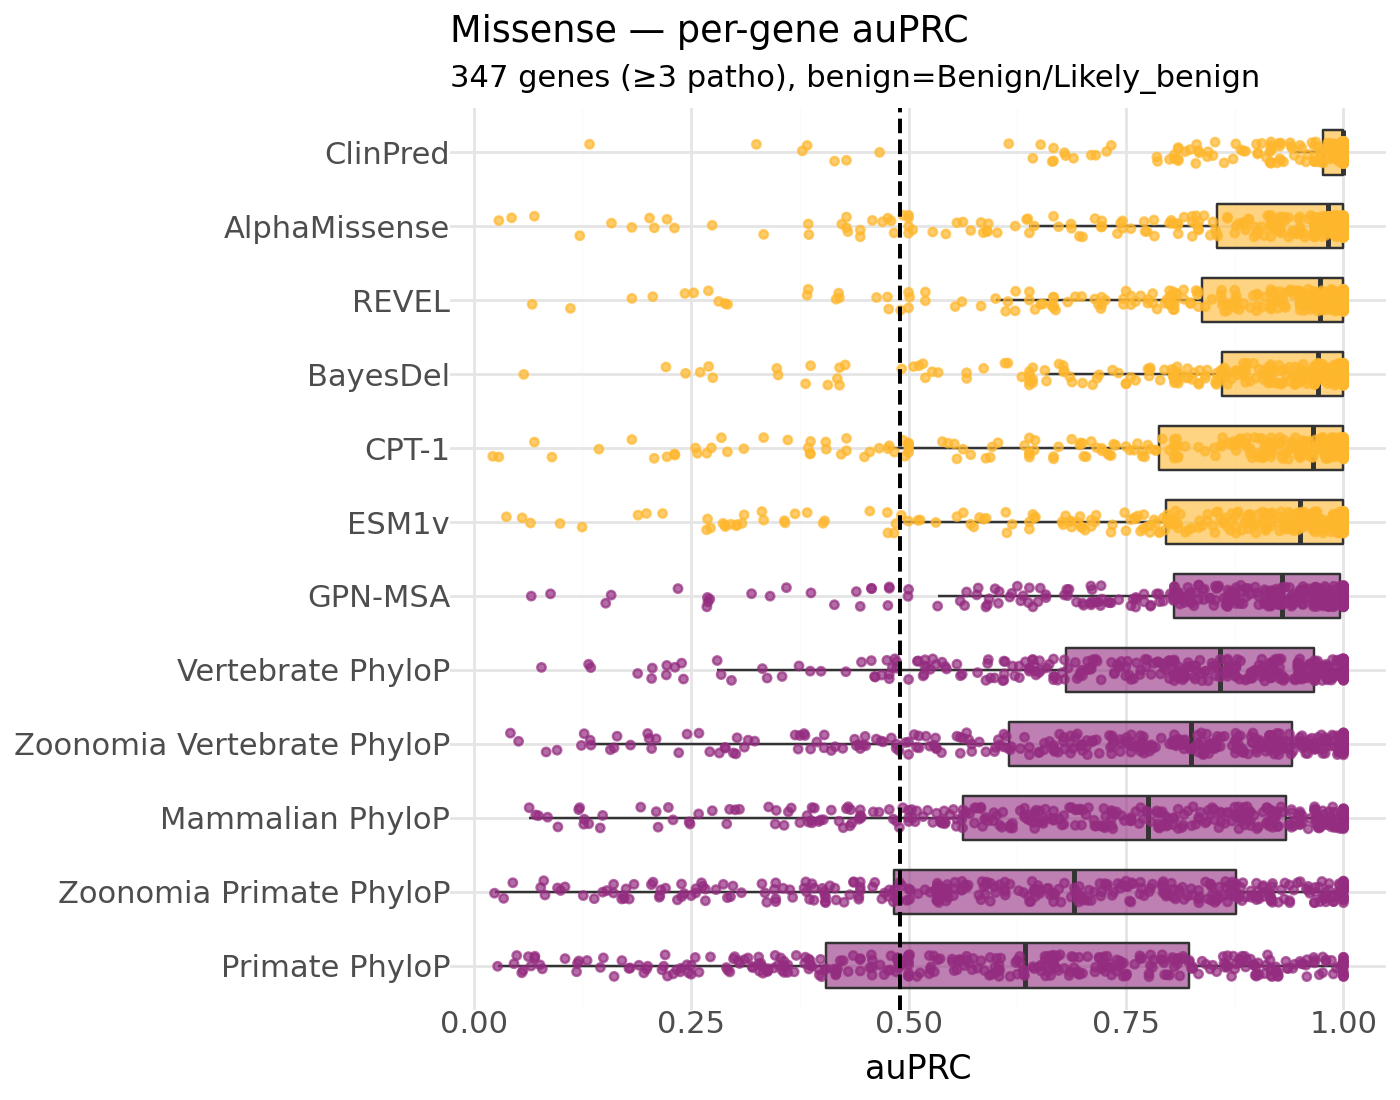

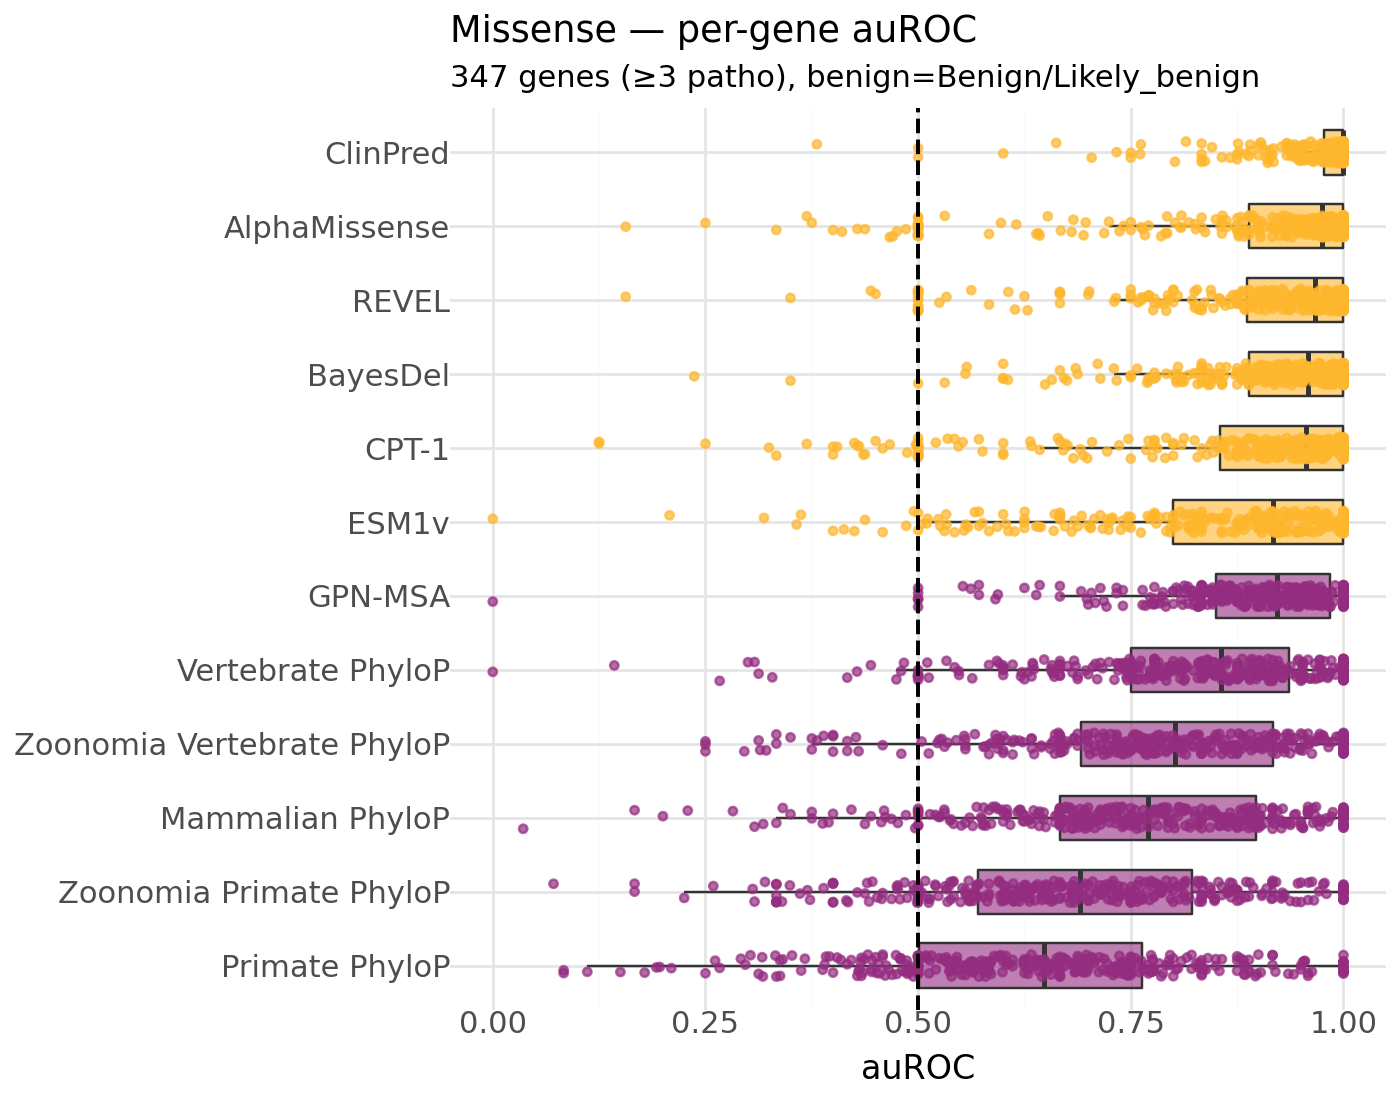

In [20]:
# Boxplot: per-gene auPRC and auROC, one box per annotation tool
benign_desc = 'all non-pathogenic' if benign_labels is None else '/'.join(benign_labels)

for vc_name in gene_results_df['variant_class'].unique().to_list():
    vc_df = gene_results_df.filter(pl.col('variant_class') == vc_name)
    x_label = vc_df['x_label'][0]
    n_genes = vc_df['region'].n_unique()

    # Global random baseline for auPRC (average across genes)
    avg_baseline = (vc_df['n_patho'] / (vc_df['n_patho'] + vc_df['n_benign'])).mean()

    # Order labels by median auPRC descending
    label_order = (
        vc_df.group_by('label')
        .agg(pl.col('auprc').median().alias('med'))
        .sort('med', descending=False)
        ['label'].to_list()
    )

    plot_df = (
        vc_df
        .with_columns(label=pl.col('label').cast(pl.Enum(label_order)))
        .to_pandas()
    )
    color_dict = dict(vc_df.select(['annotation', 'color']).unique().iter_rows())
    # Map color dict to label for fill
    anno_to_label = dict(vc_df.select(['annotation', 'label']).unique().iter_rows())
    label_color_dict = {anno_to_label[a]: c for a, c in color_dict.items()}

    for metric, x_lab, baseline in [
        ('auprc', 'auPRC', avg_baseline),
        ('auroc', 'auROC', 0.5),
    ]:
        p = (
            ggplot(plot_df, aes(x='label', y=metric, fill='label'))
            + geom_boxplot(alpha=0.6, outlier_shape='', width=0.6)
            + geom_jitter(aes(color='label'), width=0.15, size=1.2, alpha=0.7)
            + geom_hline(yintercept=baseline, linetype='dashed', color='black', size=0.8)
            + coord_flip()
            + theme_minimal()
            + scale_fill_manual(values=label_color_dict)
            + scale_color_manual(values=label_color_dict)
            + labs(
                x='', y=x_lab,
                title=f"{x_label} — per-gene {x_lab}",
                subtitle=f"{n_genes} genes (≥{MIN_PATHO_PER_GENE} patho), benign={benign_desc}",
            )
            + theme(
                figure_size=(7, len(label_order) / 3 + 1.5),
                legend_position='none',
                axis_text=element_text(size=11),
                axis_title=element_text(size=12),
                plot_background=element_rect(fill='white', color='white'),
            )
        )
        p.show()